# 02 — Hazard: ShakeMap Interpolation

**Purpose:** Interpolate ground motion intensity measures from the USGS ShakeMap
grid to individual bridge locations.

## Input Files

| File | Format | Description |
|------|--------|-------------|
| `config.yaml` | YAML | Region bounds, IM type (SA10), interpolation method |
| `data/grid.xml` | XML (USGS ShakeMap) | 215,642-point grid with PGA, PSA03, PSA10, PSA30 (in g) |
| `data/CA24.txt` | Fixed-width text (NBI) | Bridge inventory with lat/lon coordinates |

## Outputs (in-memory)

| Object | Type | Description |
|--------|------|-------------|
| `sa_nearest` | `np.ndarray` (2953,) | Nearest-neighbor interpolated Sa(1.0s) in g |
| `sa_kriging` | `np.ndarray` (2953,) | Kriging-interpolated Sa(1.0s) in g |
| `nbi["sa_10"]` | `pd.Series` | Final assigned IM column on bridge DataFrame |

## Expected Plots

- **Spatial IM map** — bridges colored by interpolated Sa(1.0s) (YlOrRd colormap), with colorbar in g

**Key concepts:** Spatial interpolation (nearest-neighbor, kriging), ShakeMap grid,
intensity measure assignment, method comparison

## Imports & Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as cx
from shapely.geometry import Point

from src.config import load_config, IM_COLUMN_MAP
from src.data_loader import load_shakemap, load_nbi, classify_nbi_to_hazus
from src.interpolation import interpolate_im

pd.set_option("display.max_columns", 20)
%matplotlib inline

## Step 1: Load Data

In [2]:
cfg = load_config(PROJECT_ROOT / "config.yaml")

grid = load_shakemap(PROJECT_ROOT / "data" / "grid.xml")
nbi = load_nbi(PROJECT_ROOT / "data" / "CA24.txt", northridge_bbox=cfg.region)
nbi = classify_nbi_to_hazus(nbi)

# Determine which ShakeMap column to use
im_col = IM_COLUMN_MAP.get(cfg.im_type, "PSA10")
print(f"IM type: {cfg.im_type} → ShakeMap column: {im_col}")
print(f"Grid points: {len(grid)}, Bridges: {len(nbi)}")

IM type: SA10 → ShakeMap column: PSA10
Grid points: 215642, Bridges: 2953


## Step 2: Nearest-Neighbor Interpolation

The simplest method — each bridge gets the IM value of the closest grid point.
Fast but can be inaccurate near sharp gradients.

**Input:** `grid` (LAT, LON, PSA10 arrays) + `nbi` (latitude, longitude arrays)
**Output:** `sa_nearest` — float array, shape (2953,), Sa(1.0s) in g
**Expected range:** ~0.06 – 1.26 g, mean ~0.32 g

In [3]:
sa_nearest = interpolate_im(
    grid_lats=grid["LAT"].values,
    grid_lons=grid["LON"].values,
    grid_values=grid[im_col].values,
    bridge_lats=nbi["latitude"].values,
    bridge_lons=nbi["longitude"].values,
    method="nearest",
)

print(f"Nearest-neighbor interpolation:")
print(f"  Min:  {sa_nearest.min():.4f} g")
print(f"  Max:  {sa_nearest.max():.4f} g")
print(f"  Mean: {sa_nearest.mean():.4f} g")
print(f"  Std:  {sa_nearest.std():.4f} g")

Nearest-neighbor interpolation:
  Min:  0.0640 g
  Max:  1.2610 g
  Mean: 0.3211 g
  Std:  0.2644 g


## Step 3: Kriging Interpolation

Ordinary kriging provides optimal (BLUE) interpolation by modeling spatial
autocorrelation. More accurate than nearest-neighbor but slower.

**Parameters:** `range_km=50.0` (variogram range), `nugget=0.01` (measurement noise)
**Output:** `sa_kriging` — same shape as `sa_nearest`, typically within ~0.02 g RMSE of nearest

In [4]:
sa_kriging = interpolate_im(
    grid_lats=grid["LAT"].values,
    grid_lons=grid["LON"].values,
    grid_values=grid[im_col].values,
    bridge_lats=nbi["latitude"].values,
    bridge_lons=nbi["longitude"].values,
    method="kriging",
    range_km=50.0,
    nugget=0.01,
)

print(f"Kriging interpolation:")
print(f"  Min:  {sa_kriging.min():.4f} g")
print(f"  Max:  {sa_kriging.max():.4f} g")
print(f"  Mean: {sa_kriging.mean():.4f} g")
print(f"  Std:  {sa_kriging.std():.4f} g")

Kriging interpolation:
  Min:  0.0653 g
  Max:  1.2431 g
  Mean: 0.3192 g
  Std:  0.2616 g


In [5]:
# Compare methods
diff = sa_kriging - sa_nearest
print(f"\nDifference (kriging - nearest):")
print(f"  Mean diff: {diff.mean():.5f} g")
print(f"  Max |diff|: {np.abs(diff).max():.5f} g")
print(f"  RMSE: {np.sqrt((diff**2).mean()):.5f} g")


Difference (kriging - nearest):
  Mean diff: -0.00185 g
  Max |diff|: 0.15070 g
  RMSE: 0.02268 g


## Step 4: Assign IM to Bridges

**Output:** `nbi` DataFrame now includes `sa_10` column (float, Sa(1.0s) in g).
**Expected display:** 20-row table with structure_number, latitude, longitude, hwb_class, sa_10.

In [6]:
# Use the configured interpolation method
nbi["sa_10"] = sa_nearest  # default: nearest

display(
    nbi[["structure_number", "latitude", "longitude", "hwb_class", "sa_10"]]
    .head(20)
)

,structure_number,latitude,longitude,hwb_class,sa_10
0,52 0036,34.400708,-118.827000,HWB17,0.3974
1,52 0037,34.408781,-118.787797,HWB1,0.3533
2,52 0046,34.143069,-118.849192,HWB17,0.2087
3,52 0237,34.177492,-118.876247,HWB17,0.2727
4,52 0268E,34.157158,-118.825219,HWB7,0.2873
5,52 0273,34.166164,-118.837600,HWB17,0.2929
6,52 0274,34.171808,-118.846039,HWB17,0.2415
7,52 0282,34.278867,-118.662336,HWB17,0.5431
8,52 0283,34.268092,-118.635794,HWB17,0.5065
9,52 0299,34.281439,-118.709178,HWB17,0.7572


## Step 5: Spatial Map of Interpolated IM

**Expected plot:** Scatter map with OpenStreetMap basemap. Bridges colored by Sa(1.0s) (YlOrRd colormap) with colorbar in g. Blue star marks epicenter. Higher IM (warmer colors) clusters near the epicenter.

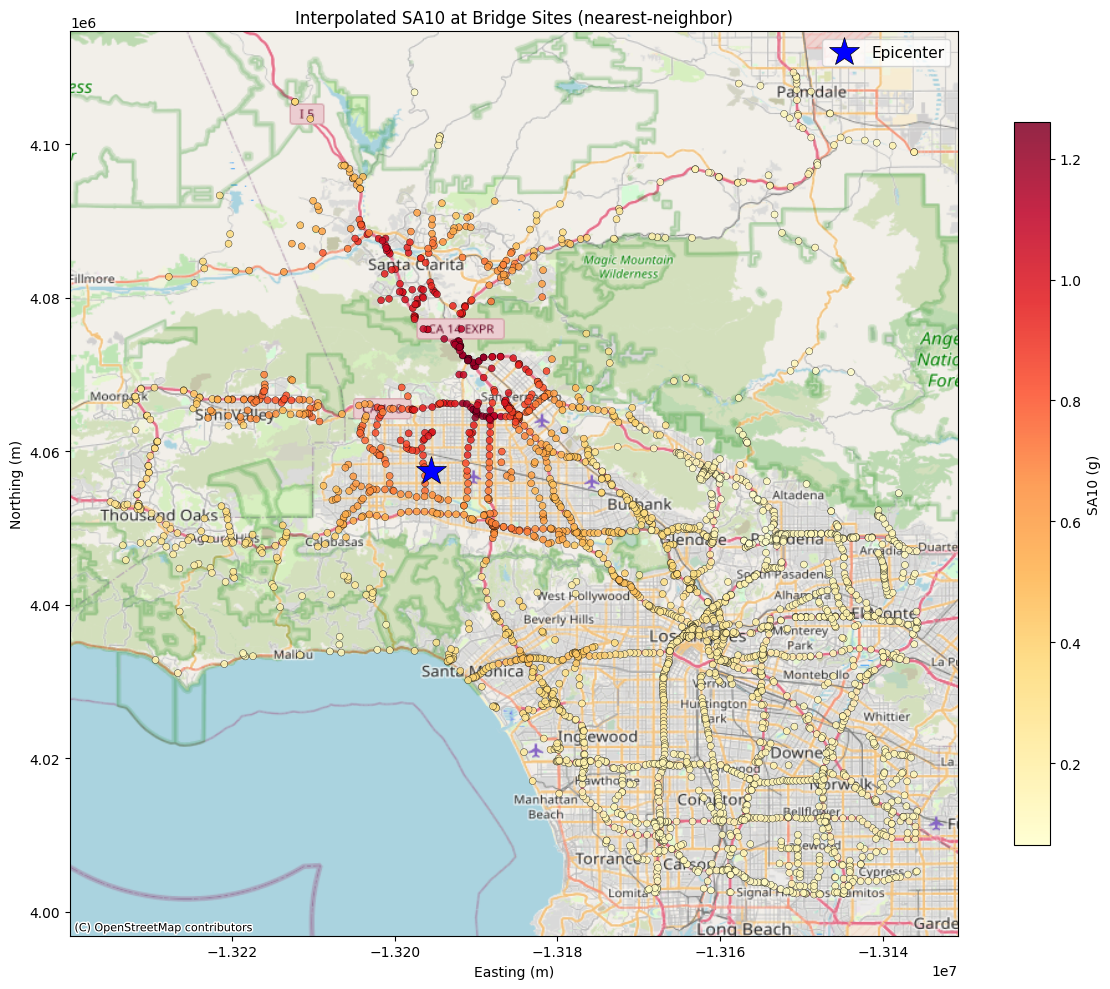

In [7]:
# Build GeoDataFrame and reproject for basemap
gdf = gpd.GeoDataFrame(
    nbi,
    geometry=[Point(xy) for xy in zip(nbi["longitude"], nbi["latitude"])],
    crs="EPSG:4326",
).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))

sc = ax.scatter(
    gdf.geometry.x, gdf.geometry.y,
    c=gdf["sa_10"], cmap="YlOrRd",
    s=25, alpha=0.85, edgecolors="k", linewidths=0.3,
    zorder=5,
)
cbar = plt.colorbar(sc, ax=ax, label=f"{cfg.im_type} (g)", shrink=0.8)

# Epicenter
epi = gpd.GeoDataFrame(
    geometry=[Point(-118.537, 34.213)], crs="EPSG:4326"
).to_crs(epsg=3857)
ax.plot(epi.geometry.x, epi.geometry.y, "b*", markersize=22,
        markeredgecolor="k", markeredgewidth=0.5, label="Epicenter", zorder=6)

cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, zoom=10)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title(f"Interpolated {cfg.im_type} at Bridge Sites (nearest-neighbor)")
ax.legend(loc="upper right", fontsize=11)
plt.tight_layout()
plt.show()

## Summary

In this notebook we:
1. Loaded the ShakeMap grid and bridge inventory
2. Interpolated Sa(1.0s) to bridge sites using nearest-neighbor
3. Compared with kriging interpolation
4. Visualized the spatial distribution of IM at bridge sites

**Next:** [03_hazard_gmpe.ipynb](03_hazard_gmpe.ipynb) — Compute IM via BSSA21 GMPE